# Plot pcFVA Results

In [1]:
from pathlib import Path
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.gridspec import GridSpec

In [2]:
model_id = "RBC3P_expanded"
dataset_name = "RBComics_G6PD"
data_path = Path("../../../../data/analysis/OVERLAY").resolve()
root_path = Path("../../../..").resolve()
results_path = root_path / "data" / "processed" / model_id / "OVERLAY"
pcmodel_dirpath = data_path / model_id
dataset_path = results_path / dataset_name
dataset_models_dirpath = dataset_path / "pcmodels"
pcfva_results_dirpath = dataset_path / "pcFVA"
corr_results_dirpath = dataset_path / "correlations"
df_pcfva_all_filename = pcfva_results_dirpath / f"{model_id}_PC_FVAresults_ALL.tsv"
model_filename = pcmodel_dirpath / f"{model_id}.xml"
pcmodel_filename = pcmodel_dirpath / f"{model_id}_PC.xml"
correlations2_dirpath = dataset_path / "correlations2"
flux_plots_path = dataset_path / "flux_plots"

print(results_path)
print(pcmodel_dirpath)
print(dataset_path)
print(dataset_models_dirpath)
print(pcfva_results_dirpath)
print(corr_results_dirpath)
print(df_pcfva_all_filename)
print(model_filename)
print(pcmodel_filename)
print(correlations2_dirpath)
print(flux_plots_path)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcmodels
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA\RBC3P_expanded_PC_FVAresults_ALL.tsv
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded\RBC3P_expanded.xml
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded\RBC3P_expanded_PC.xml
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations2
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots


In [3]:
df_flux_abundance_correlation_filename = (
    correlations2_dirpath / "df_flux_abundance_correlation.csv"
)
df_flux_abundance_correlation = pd.read_csv(df_flux_abundance_correlation_filename)
df_flux_abundance_correlation

,Unnamed: 0,reactions,rho,raw_p_value,adj_p_value,neg_log10_adj_p_value,abundance_dependence,category
0,0,ADA,-0.069060,3.135064e-03,4.068913e-03,2.390522,Independent,Nucleotide metabolism
1,1,ADEt,-0.078595,7.702784e-04,1.021456e-03,2.990780,Independent,Transport reactions
2,2,ADK1,-0.096827,3.372097e-05,4.783672e-05,4.320239,Independent,Nucleotide metabolism
3,3,ADNK1,0.238054,5.734865e-25,1.249381e-24,23.903305,Independent,Nucleotide metabolism
4,4,ADNt,0.511792,1.361003e-122,4.151060e-122,121.381841,Correlated,Transport reactions
...,...,...,...,...,...,...,...,...
56,56,SPODM,0.058384,1.253744e-02,1.560783e-02,1.806657,Independent,Reactive species
57,57,TALA,0.083149,3.725993e-04,5.165582e-04,3.286881,Independent,Carbohydrate metabolism
58,58,TKT1,0.208445,2.155061e-19,4.108084e-19,18.386361,Independent,Carbohydrate metabolism
59,59,TKT2,0.208445,2.155061e-19,4.108084e-19,18.386361,Independent,Carbohydrate metabolism


In [4]:
def plot_correlations(
    df, vertical_lines, ax=None, histx=True, histy=True, colorbar=True, **kwargs
):
    # Define figure if no axes provided.
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.25)
    if ax is None:
        _, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(
                scatter_inch + (hist_inch + hist_pad if histy else 0),
                scatter_inch + (hist_inch + hist_pad if histx else 0),
            ),
        )
    xy = {"x": "rho", "y": "neg_log10_adj_p_value"}
    limits = {
        "x": (kwargs.get("xmin", -1.0), kwargs.get("xmax", 1.0)),
        "y": (kwargs.get("ymin", 0.0), kwargs.get("ymax", df[xy["y"]].max())),
    }
    pads = {
        axis: kwargs.get(f"{axis}pad", (limits[axis][1] - limits[axis][0]) / 2 / 20)
        for axis in list(xy)
    }
    cmap = kwargs.get("cmap", "viridis")
    zorder = kwargs.get("zorder", 2)
    edgecolor = kwargs.get("edgecolor", "black")
    edgewidth = kwargs.get("edgewidth", 0.5)
    scatter = ax.scatter(
        xy["x"],
        xy["y"],
        data=df,
        c=kwargs.get("c", xy["y"]),
        s=kwargs.get("s", 40),
        alpha=0.5,
        zorder=zorder,
        edgecolor=edgecolor,
        linewidth=edgewidth,
        cmap=mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap,
        norm=mpl.colors.Normalize(
            vmin=limits["y"][0] - pads["y"], vmax=limits["y"][1] + pads["y"]
        ),
    )
    ax.set_xlabel(r"Spearman Correlation $(\rho)$", fontdict={"size": "xx-large"})
    ax.set_ylabel("-log$_{10}$(adj p-value)", fontdict={"size": "xx-large"})
    ax.set_xlim((limits["x"][0] - pads["x"], limits["x"][1] + pads["x"]))
    ax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))

    major_ticks = {axis: kwargs.get(f"{axis}tick_major") for axis in list(xy)}
    minor_ticks = {
        axis: kwargs.get(
            f"{axis}tick_minor",
            major_ticks[axis] / 2 if major_ticks[axis] is not None else None,
        )
        for axis in list(xy)
    }
    for axis in list(xy):
        if major_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_major_locator(
                mpl.ticker.MultipleLocator(major_ticks[axis])
            )
        if minor_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_minor_locator(
                mpl.ticker.MultipleLocator(minor_ticks[axis])
            )
        ax.tick_params(axis=axis, labelsize="large")

    if vertical_lines:
        for lineval, (lineprops, textprops) in vertical_lines.items():
            if lineprops:
                ax.vlines(
                    x=lineval,
                    ymin=limits["y"][0] - pads["y"],
                    ymax=limits["y"][1] + pads["y"],
                    **lineprops,
                )
            if textprops:
                ax.text(x=lineval + pads["x"] / 2, transform=ax.transData, **textprops)

    if kwargs.get("grid", False):
        ax.grid(True, **dict(which="both", alpha=0.75))

    if colorbar:
        cax = ax.inset_axes(
            [
                limits["x"][0] - pads["x"],  # lower left corner xpos
                limits["y"][0] - pads["y"],  # lower left corner ypos
                pads["x"],  # width of colorbar
                limits["y"][1]
                + pads["y"]
                + pads[
                    "y"
                ],  # height of colorbar, need extra ypad to make up for lowering ypos
            ],
            transform=ax.transData,
        )
        cbar = ax.get_figure().colorbar(scatter, cax=cax)
        cax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))
        cax.set_xticks([])
        cax.set_yticks([])

    ax_histx = None
    ax_histy = None
    if histx or histy:
        divider = make_axes_locatable(ax)
        # Histogram axes
        ax_histx = (
            divider.append_axes("top", hist_inch, pad=hist_pad, sharex=ax)
            if histx
            else None
        )
        ax_histy = (
            divider.append_axes("right", hist_inch, pad=hist_pad, sharey=ax)
            if histy
            else None
        )

        for axis, ax_hist in zip(list(xy), [ax_histx, ax_histy]):
            if ax_hist is None:
                continue
            binwidth = kwargs.get(
                f"{axis}binwidth",
                (
                    minor_ticks[axis]
                    if minor_ticks[axis] is not None
                    else major_ticks[axis]
                ),
            )
            counts, bins, patches = ax_hist.hist(
                df[xy[axis]],
                bins=np.arange(limits[axis][0], limits[axis][1] + binwidth, binwidth),
                orientation="vertical" if axis == "x" else "horizontal",
                zorder=zorder,
                edgecolor=edgecolor,
                linewidth=edgewidth,
            )
            other = "y" if axis == "x" else "x"
            ax_hist.tick_params(
                axis=axis, **{f"label{'bottom' if axis == 'x' else 'left'}": False}
            )
            ax_hist.tick_params(axis=other, labelsize="large")
            getattr(ax_hist, f"set_{other}label")("Frequency", fontsize="large")

            tick_major_int = kwargs.get(f"hist{axis}_{other}tick_major")
            if tick_major_int is not None:
                getattr(ax_hist, f"{other}axis").set_major_locator(
                    mpl.ticker.MultipleLocator(tick_major_int)
                )
                getattr(ax_hist, f"{other}axis").set_minor_locator(
                    mpl.ticker.MultipleLocator(tick_major_int / 2)
                )
            getattr(ax_hist, f"set_{other}lim")((0, max(counts) * 1.1))
            if kwargs.get("grid", False):
                ax_hist.grid(True, **dict(which="both", alpha=0.75))

            if vertical_lines and (axis == "x" and ax_hist is not None):
                for lineval, (lineprops, _) in vertical_lines.items():
                    if lineprops:
                        ax_hist.vlines(
                            x=lineval, ymin=0.0, ymax=max(counts) * 1.1, **lineprops
                        )

    return ax, ax_histx, ax_histy

In [5]:
def make_flux_abundance_u_plot(df, histx=True, histy=True, colorbar=True, **kwargs):
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.5)
    nrows, ncols = (1, 1)
    expression_dep_rho_lb = 0.8
    expression_cor_rho_lb = 0.5
    ypos = 4
    ww = 11
    rotation = 90
    fontsize = "large"
    linewidth = 2
    vertical_lines = {
        expression_dep_rho_lb: (
            dict(color="black", linestyle="-", linewidth=linewidth),
            dict(
                y=ypos,
                s="\n".join(textwrap.wrap("Expression dependent", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
        expression_cor_rho_lb: (
            dict(color="xkcd:dark grey", linestyle="--", linewidth=linewidth),
            dict(
                y=ypos,
                s="\n".join(textwrap.wrap("Expression correlated", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
        0.0: (
            dict(),
            dict(
                y=ypos + 50.0,
                s="\n".join(textwrap.wrap("Expression independent", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
    }
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
            (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
        ),
    )
    ax_scatter, ax_histx, ax_histy = plot_correlations(
        df,
        ax=ax,
        histx=histx,
        histy=histy,
        colorbar=True,
        vertical_lines=vertical_lines,
        xbinwidth=0.1,
        ybinwidth=10,
        **kwargs,
    )
    # ax_scatter.set_title(
    #     f"Correlates between Flux and Abundance",
    #     fontsize="x-large",
    # )
    fig.suptitle("Correlates between Flux and Abundance", fontsize=18)

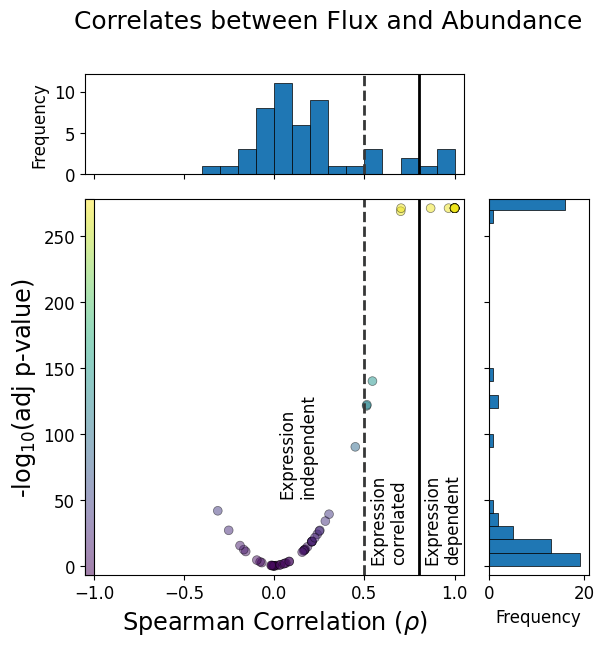

In [6]:
make_flux_abundance_u_plot(df_flux_abundance_correlation)

### Donut charts of subsystems

Look at categories and subsystems here: [KEGG pathways](https://www.kegg.jp/kegg/pathway.html) Look at "category" in df_pathways.

In [7]:
df_flux_abundance_correlation["category"].unique()

array(['Nucleotide metabolism', 'Transport reactions',
       'Metabolism of cofactors and vitamins', 'Carbohydrate metabolism',
       'Reactive species', 'Metabolism of other amino acids'],
      dtype=object)

In [8]:
def map_categories_to_colors(categories):
    color_for_category = {
        "Nucleotide metabolism": "#332288",
        "Transport reactions": "#117733",
        "Metabolism of cofactors and vitamins": "#44AA99",
        "Carbohydrate metabolism": "#88CCEE",
        "Reactive species": "#999933",
        "Metabolism of other amino acids": "#DDCC77",
    }
    return [color_for_category[category] for category in categories]

In [9]:
def make_subsystem_breakdown_by_abundance_dependence(
    df, abundance_dependence, figsize=(8, 8), title_y=1.2, center_title=None
):
    color_for_category = {
        "Nucleotide metabolism": "#332288",
        "Transport reactions": "#117733",
        "Metabolism of cofactors and vitamins": "#44AA99",
        "Carbohydrate metabolism": "#88CCEE",
        "Reactive species": "#999933",
        "Metabolism of other amino acids": "#DDCC77",
    }
    ring_series = df[df["abundance_dependence"] == abundance_dependence]["category"]
    ring_series = ring_series.value_counts()
    wedge_labels = [
        f"{value}: {'\n'.join(textwrap.wrap(index, width=20))}"
        for index, value in ring_series.items()
    ]
    wedge_colors = [color_for_category[category] for category, _ in ring_series.items()]
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    wedges, texts = ax.pie(
        ring_series,
        labels=wedge_labels,
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        colors=wedge_colors,
        labeldistance=1.2,
    )
    center_circle = plt.Circle((0, 0), 0.75, fc="white")
    ax.add_artist(center_circle)
    ax.set_aspect("equal")
    formatted_center_title = (
        f"{center_title}\n{sum(ring_series)}" if center_title else sum(ring_series)
    )
    ax.text(0, 0, formatted_center_title, ha="center", va="center", fontsize=12)
    plt.title(abundance_dependence, fontsize=14, y=title_y)

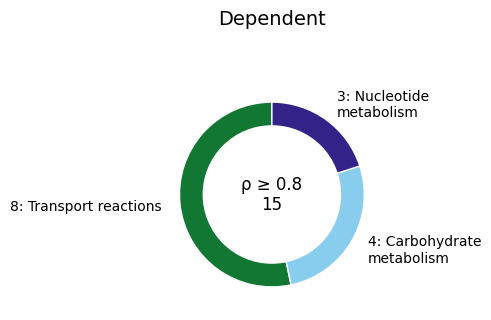

In [10]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation,
    abundance_dependence="Dependent",
    figsize=(3, 3),
    center_title="ρ ≥ 0.8",
)

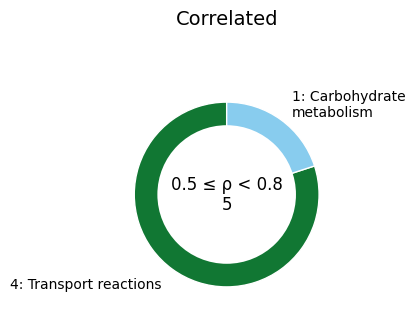

In [11]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation,
    abundance_dependence="Correlated",
    figsize=(3, 3),
    center_title="0.5 ≤ ρ < 0.8",
)

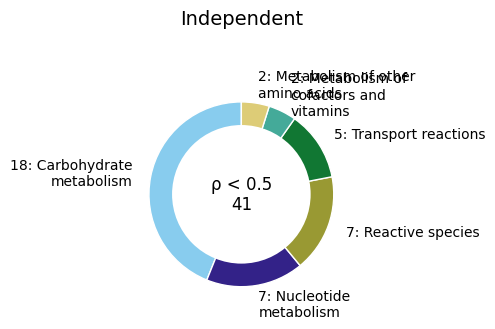

In [12]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation,
    abundance_dependence="Independent",
    figsize=(3, 3),
    center_title="ρ < 0.5",
)

TODO: Make pathway map. Use Escher and instead of edge weights being fluxes, correlation coefficients.

### Gene reaction counts horizontal bar charts

In [13]:
df_gene_reaction_count_filename = correlations2_dirpath / "df_gene_reaction_count.csv"
df_gene_reaction_count = pd.read_csv(df_gene_reaction_count_filename)
df_gene_reaction_count

,abundance_dependence,genes,category,reactions
0,Correlated,BSG;EMB;SLC16A1;SLC16A7,Transport reactions,2
1,Correlated,SLC29A1,Transport reactions,2
2,Correlated,ENO1;ENO2;ENO3,Carbohydrate metabolism,1
3,Dependent,NT5C2,Nucleotide metabolism,2
4,Dependent,AMPD3,Nucleotide metabolism,1
5,Dependent,AQP1,Transport reactions,1
6,Dependent,AQP1;AQP3,Transport reactions,1
7,Dependent,AQP1;AQP3;RHAG;RHCE;RHD,Transport reactions,1
8,Dependent,AQP1;RHAG;RHCE;RHD,Transport reactions,1
9,Dependent,ATP2B1;ATP2B4,Transport reactions,1


In [14]:
def make_gene_reaction_count_plot(df, abundance_dependence, **kwargs):
    df1 = df[df["abundance_dependence"] == abundance_dependence][
        ["reactions", "genes", "category"]
    ]
    df1.set_index("genes", inplace=True)
    fig, ax = plt.subplots(nrows=1, ncols=1, **kwargs)
    ax.barh(
        df1.index, df1["reactions"], color=map_categories_to_colors(df1["category"])
    )

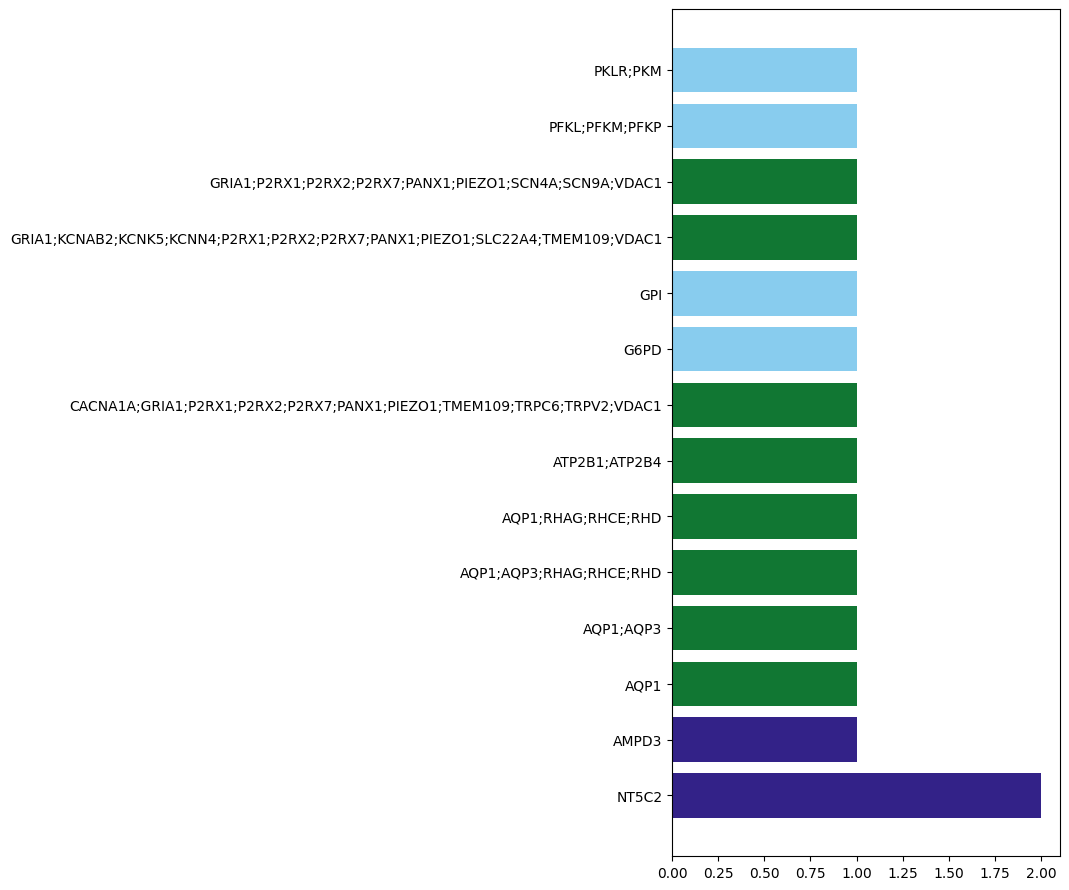

In [15]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Dependent", figsize=(5, 11))

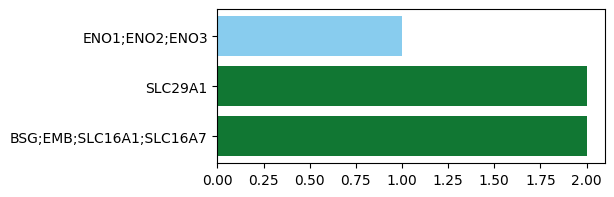

In [16]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Correlated", figsize=(5, 2))

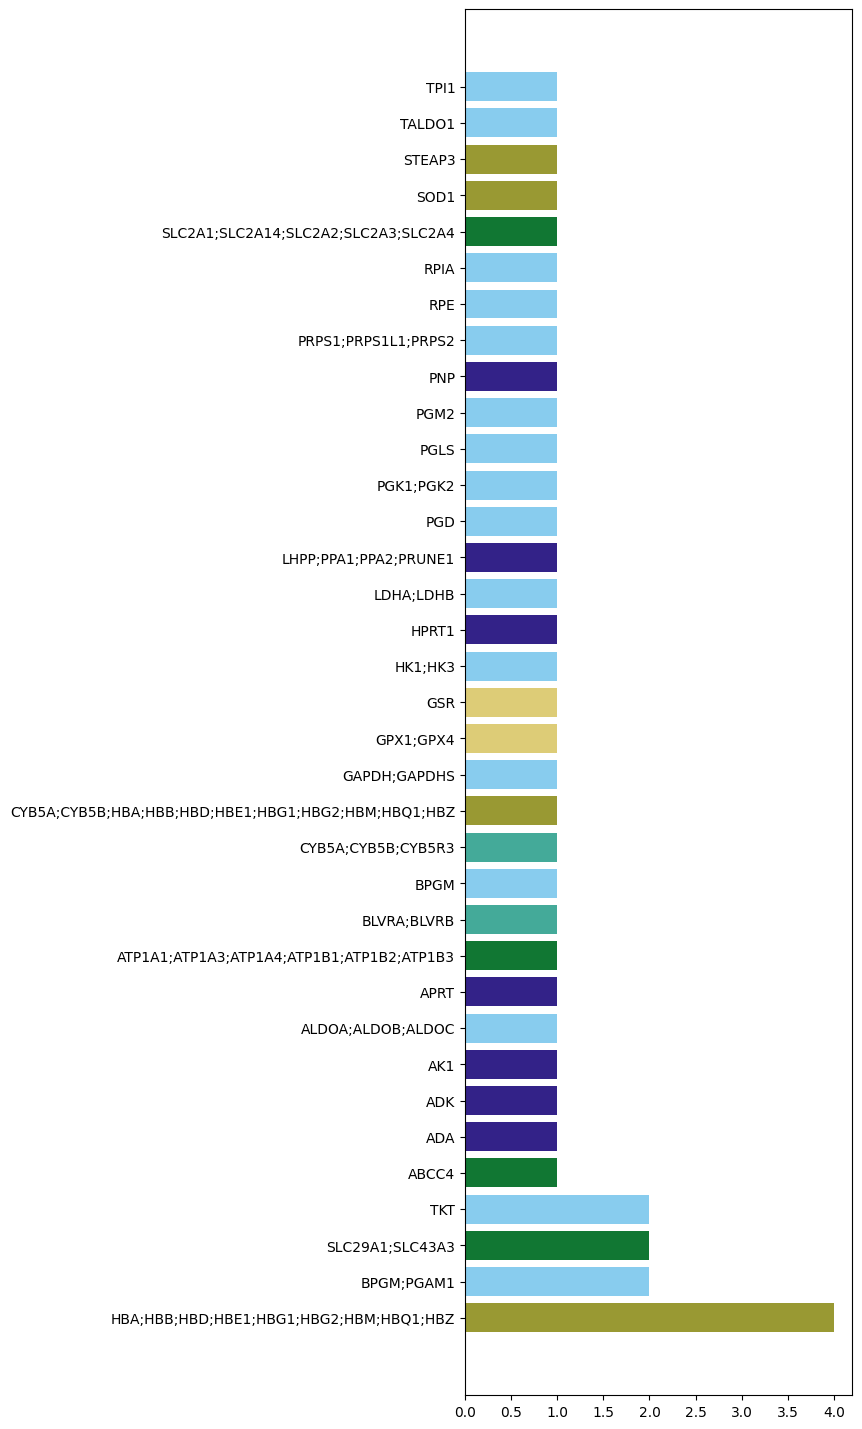

In [17]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Independent", figsize=(5, 18))

### Plot solution space of by day, reaction, and G6PD_allele

In [18]:
df_pcfva_alleles_filename = correlations2_dirpath / "df_pcfva_alleles.csv"
df_pcfva_alleles = pd.read_csv(df_pcfva_alleles_filename)
df_pcfva_alleles.drop("sample_id", axis=1, inplace=True)
df_pcfva_alleles.set_index(
    ["G6PD_alleles", "day", "reactions", "optimum"], inplace=True
)
df_pcfva_alleles

minimum   maximum     range
G6PD_alleles day reactions optimum                             
0            10  ADA       0.00         0.0  0.279580  0.279580
             23  ADA       0.00         0.0  0.358696  0.358696
             42  ADA       0.00         0.0  0.310495  0.310495
             10  ADA       0.00         0.0  0.296455  0.296455
             23  ADA       0.00         0.0  0.302056  0.302056
...                                     ...       ...       ...
                 TPI       0.99         0.0  0.001753  0.001753
             42  TPI       0.99         0.0  0.001790  0.001790
             10  TPI       0.99         0.0  0.001541  0.001541
             23  TPI       0.99         0.0  0.001325  0.001325
             42  TPI       0.99         0.0  0.001396  0.001396

[7780320 rows x 3 columns]

In [19]:
fluxes_to_plot = [
    ["HEX1", "PGI", "PFK", "TPI", "FBA"],  # Glycolysis
    ["GAPD", "PGK", "PGM", "ENO", "PYK"],  # Glycolysis
    ["G6PDH2", "BILIREDy", "FE2O2OX", "FE3RD", "FE2H2O2X"],  # PPP
    ["LDH_L", "DPGM", "DPGase", "HB23DPGB", "NaKt"],  # Hemoglobin and objective
]
fluxes_to_plot_np = np.array(fluxes_to_plot)

In [20]:
def make_optimum_min_max_plot(
    day, reaction, optima=None, optimum_colors=None, save_filename=None, **kwargs
):
    optima = [0.0, 0.5, 0.9, 0.99] if not optima else optima
    optimum_colors = (
        ["#87CEEB", "#3399CC", "#004C99", "#000080"]
        if not optimum_colors
        else optimum_colors
    )
    fig, axs = plt.subplots(nrows=1, ncols=3, sharey=True, **kwargs)
    for allele_count, (ax_idx, ax) in zip(range(3), enumerate(axs)):
        for optimum, optimum_color in zip(optima, optimum_colors):
            df_for_plot = df_pcfva_alleles.loc[
                (allele_count, day, reaction, optimum), :
            ].sort_values(by="range")
            y_mins = df_for_plot["minimum"]
            y_maxs = df_for_plot["maximum"]
            xs = np.arange(1, len(y_maxs) + 1)
            ax.fill_between(
                xs,
                y_mins,
                y_maxs,
                color=optimum_color,
                label=f"{optimum*100:.0f}% Max NaKt",
            )
            ax.set_xlabel(allele_count, fontsize=14)
            ax.set_xticks([])
            if ax_idx == 0:
                ax.set_ylabel("Flux (mmol/gDW/hr)", fontsize=14)
            if ax_idx == 2:
                ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.suptitle(f"{reaction}, Day {day}", fontsize=18)
    if save_filename:
        plt.savefig(save_filename, dpi=300, transparent=False, bbox_inches="tight", pad_inches=0.5, format="png")

C:\Users\Alicia Key\AppData\Local\Temp\ipykernel_42888\3842349254.py:13: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_for_plot = df_pcfva_alleles.loc[


D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\HEX1.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PGI.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PFK.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\TPI.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\FBA.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\GAPD.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PGK.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\PGM.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots\ENO.png saved
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComic

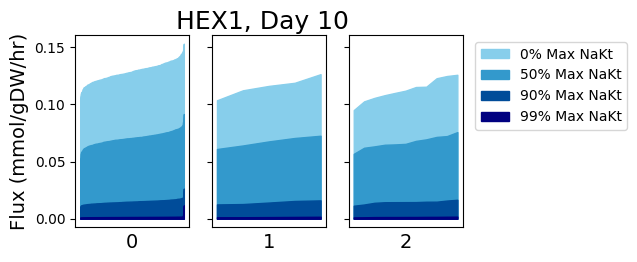

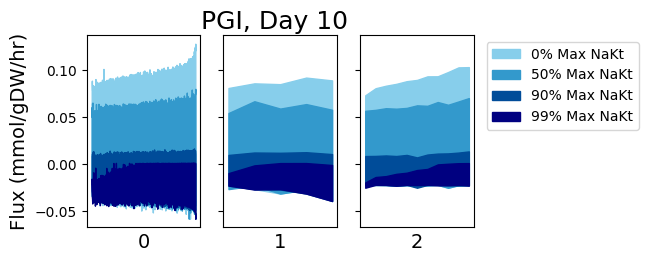

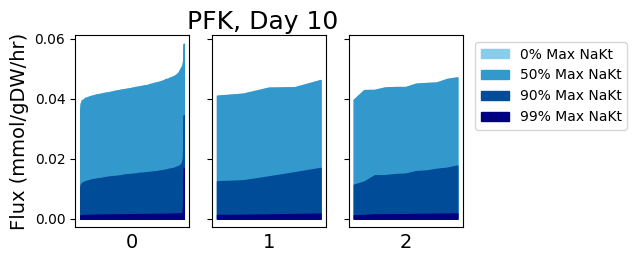

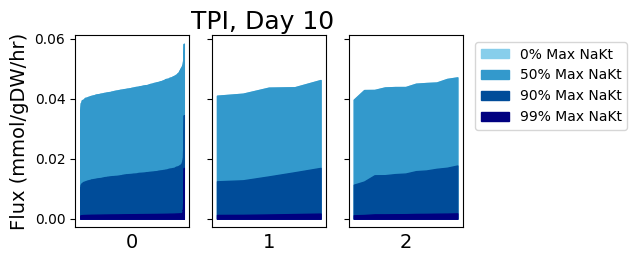

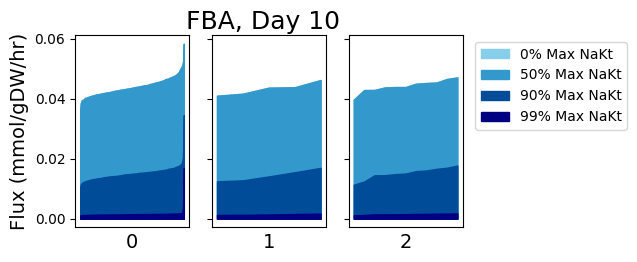

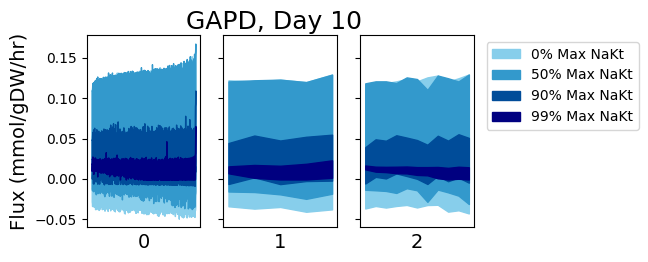

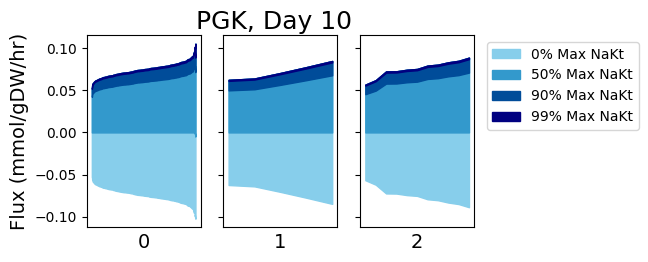

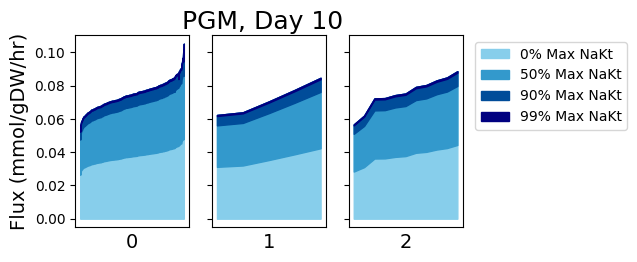

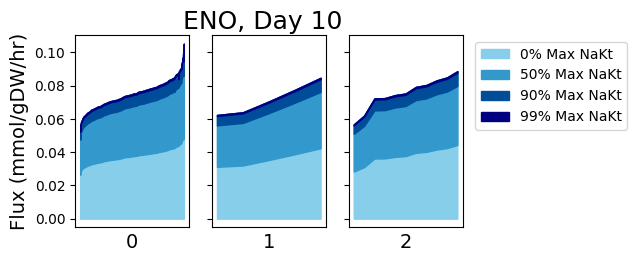

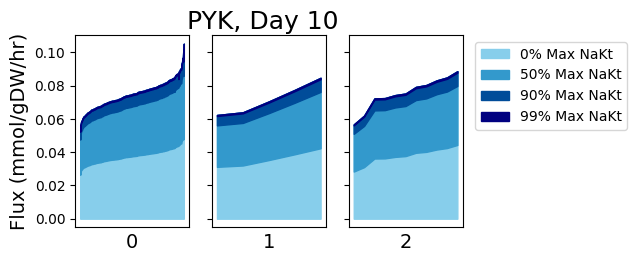

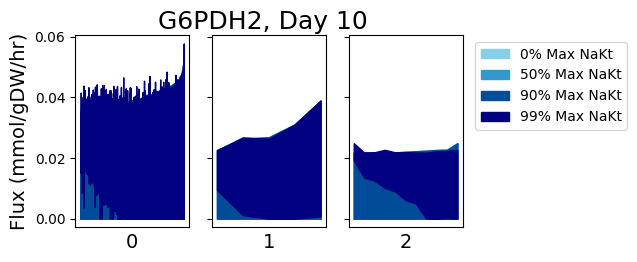

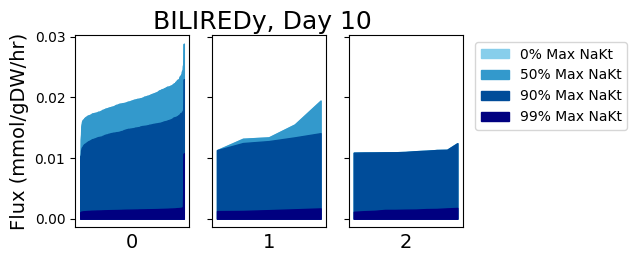

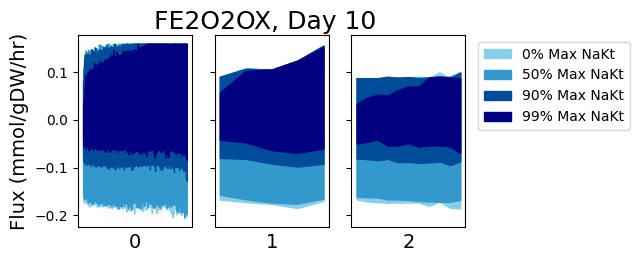

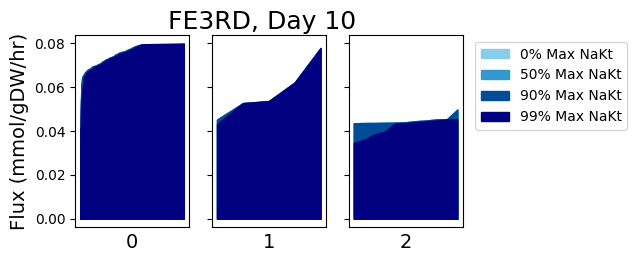

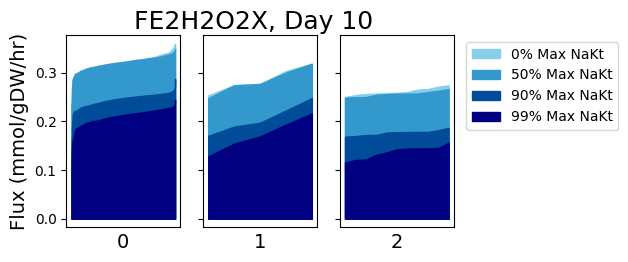

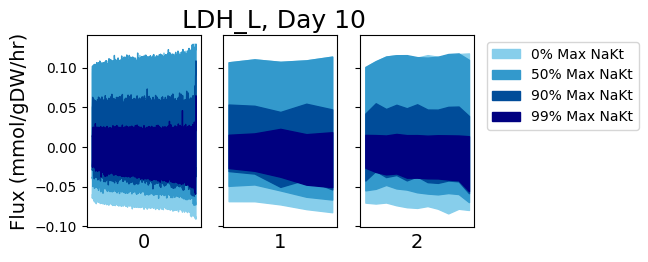

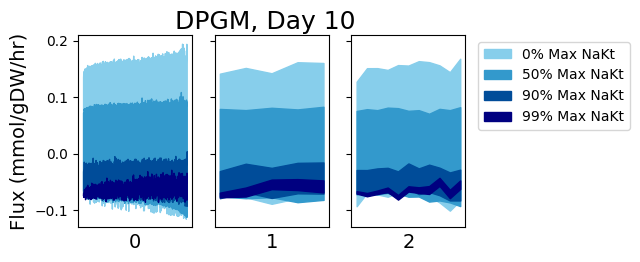

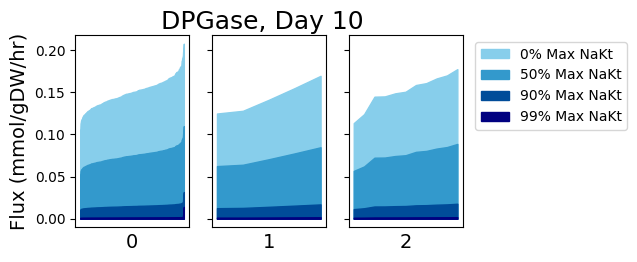

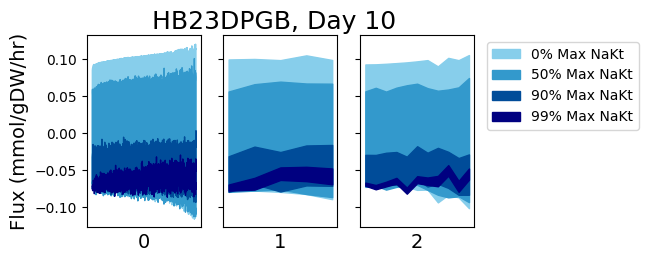

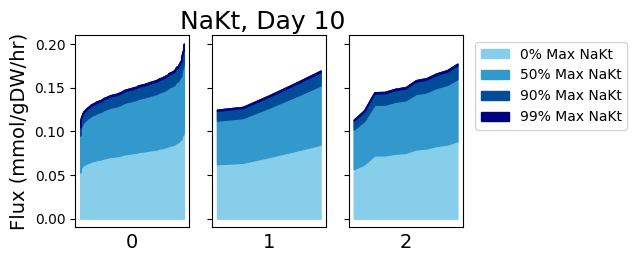

In [21]:
for flux in fluxes_to_plot_np.flatten():
    save_filename = flux_plots_path / f"{flux}.png"
    make_optimum_min_max_plot(10, flux, figsize=(5, 2.5), save_filename=save_filename)
    print(save_filename, "saved")

### Combine these plots onto one plot with small multiples

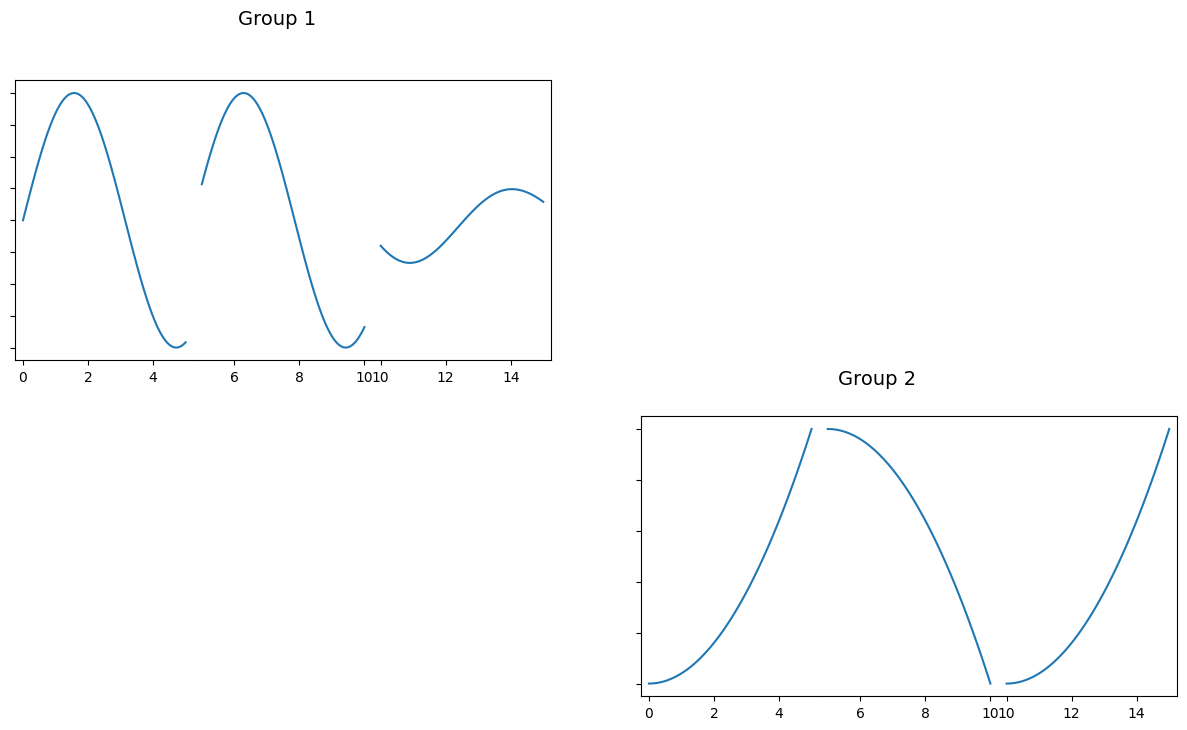

In [22]:
# Create example data
x1 = np.linspace(0, 5, 100)
y1 = np.sin(x1)
x2 = np.linspace(5, 10, 100)
y2 = np.cos(x2)
x3 = np.linspace(10, 15, 100)
y3 = np.sin(x3) * np.exp(-x3/10)

# Second group data
x4 = np.linspace(0, 5, 100)
y4 = x4**2
x5 = np.linspace(5, 10, 100)
y5 = 25 - (x5-5)**2
x6 = np.linspace(10, 15, 100)
y6 = (x6-10)**2

# Create figure
fig = plt.figure(figsize=(15, 8))

# Create custom grid with 2 rows, with appropriate column widths
gs = GridSpec(2, 7, figure=fig, height_ratios=[1, 1], width_ratios=[1, 1, 1, 0.5, 1, 1, 1])

# First group of seamless subplots (top row)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 2], sharey=ax1)

# Second group of seamless subplots (bottom row)
ax4 = fig.add_subplot(gs[1, 4])
ax5 = fig.add_subplot(gs[1, 5], sharey=ax4)
ax6 = fig.add_subplot(gs[1, 6], sharey=ax4)

# Plot data
ax1.plot(x1, y1)
ax2.plot(x2, y2)
ax3.plot(x3, y3)
ax4.plot(x4, y4)
ax5.plot(x5, y5)
ax6.plot(x6, y6)

# Hide spines between joined plots in first group
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Hide spines between joined plots in second group
ax4.spines['right'].set_visible(False)
ax5.spines['left'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax6.spines['left'].set_visible(False)

# Remove inner tick marks for first group
ax1.tick_params(right=False)
ax2.tick_params(left=False, right=False)
ax3.tick_params(left=False)

# Remove inner tick marks for second group
ax4.tick_params(right=False)
ax5.tick_params(left=False, right=False)
ax6.tick_params(left=False)

# Remove redundant y-axis labels and ticks
ax2.set_ylabel('')
ax3.set_ylabel('')
ax5.set_ylabel('')
ax6.set_ylabel('')
ax2.set_yticklabels([])
ax3.set_yticklabels([])
ax5.set_yticklabels([])
ax6.set_yticklabels([])

# Set titles for each group
fig.text(0.3, 0.95, 'Group 1', ha='center', fontsize=14)
fig.text(0.7, 0.5, 'Group 2', ha='center', fontsize=14)

# Remove spacing between subplots within each group
plt.subplots_adjust(wspace=0)

plt.show()

In [23]:
fluxes_to_plot_np.shape

(4, 5)

In [42]:
day = 10
flux_alleles_positions = []
for row_idx, row in enumerate(fluxes_to_plot):
    flux_alleles_positions.append([])
    for col_idx, reaction in enumerate(row):
        day_reaction_alleles = [[0, day, reaction], [1, day, reaction], [2, day, reaction]]
        flux_alleles_positions[row_idx].append(day_reaction_alleles)
flux_alleles_positions

[[[[0, 10, 'HEX1'], [1, 10, 'HEX1'], [2, 10, 'HEX1']],
  [[0, 10, 'PGI'], [1, 10, 'PGI'], [2, 10, 'PGI']],
  [[0, 10, 'PFK'], [1, 10, 'PFK'], [2, 10, 'PFK']],
  [[0, 10, 'TPI'], [1, 10, 'TPI'], [2, 10, 'TPI']],
  [[0, 10, 'FBA'], [1, 10, 'FBA'], [2, 10, 'FBA']]],
 [[[0, 10, 'GAPD'], [1, 10, 'GAPD'], [2, 10, 'GAPD']],
  [[0, 10, 'PGK'], [1, 10, 'PGK'], [2, 10, 'PGK']],
  [[0, 10, 'PGM'], [1, 10, 'PGM'], [2, 10, 'PGM']],
  [[0, 10, 'ENO'], [1, 10, 'ENO'], [2, 10, 'ENO']],
  [[0, 10, 'PYK'], [1, 10, 'PYK'], [2, 10, 'PYK']]],
 [[[0, 10, 'G6PDH2'], [1, 10, 'G6PDH2'], [2, 10, 'G6PDH2']],
  [[0, 10, 'BILIREDy'], [1, 10, 'BILIREDy'], [2, 10, 'BILIREDy']],
  [[0, 10, 'FE2O2OX'], [1, 10, 'FE2O2OX'], [2, 10, 'FE2O2OX']],
  [[0, 10, 'FE3RD'], [1, 10, 'FE3RD'], [2, 10, 'FE3RD']],
  [[0, 10, 'FE2H2O2X'], [1, 10, 'FE2H2O2X'], [2, 10, 'FE2H2O2X']]],
 [[[0, 10, 'LDH_L'], [1, 10, 'LDH_L'], [2, 10, 'LDH_L']],
  [[0, 10, 'DPGM'], [1, 10, 'DPGM'], [2, 10, 'DPGM']],
  [[0, 10, 'DPGase'], [1, 10, 'DPGase'], 

In [43]:
flux_alleles_positions[0][1]

[[0, 10, 'PGI'], [1, 10, 'PGI'], [2, 10, 'PGI']]

C:\Users\Alicia Key\AppData\Local\Temp\ipykernel_42888\961446706.py:38: PerformanceWarning: indexing past lexsort depth may impact performance.
  df = df_pcfva_alleles.loc[multi_index].sort_values(by="range")
C:\Users\Alicia Key\AppData\Local\Temp\ipykernel_42888\961446706.py:38: PerformanceWarning: indexing past lexsort depth may impact performance.
  df = df_pcfva_alleles.loc[multi_index].sort_values(by="range")
C:\Users\Alicia Key\AppData\Local\Temp\ipykernel_42888\961446706.py:38: PerformanceWarning: indexing past lexsort depth may impact performance.
  df = df_pcfva_alleles.loc[multi_index].sort_values(by="range")
C:\Users\Alicia Key\AppData\Local\Temp\ipykernel_42888\961446706.py:38: PerformanceWarning: indexing past lexsort depth may impact performance.
  df = df_pcfva_alleles.loc[multi_index].sort_values(by="range")
C:\Users\Alicia Key\AppData\Local\Temp\ipykernel_42888\961446706.py:38: PerformanceWarning: indexing past lexsort depth may impact performance.
  df = df_pcfva_alle

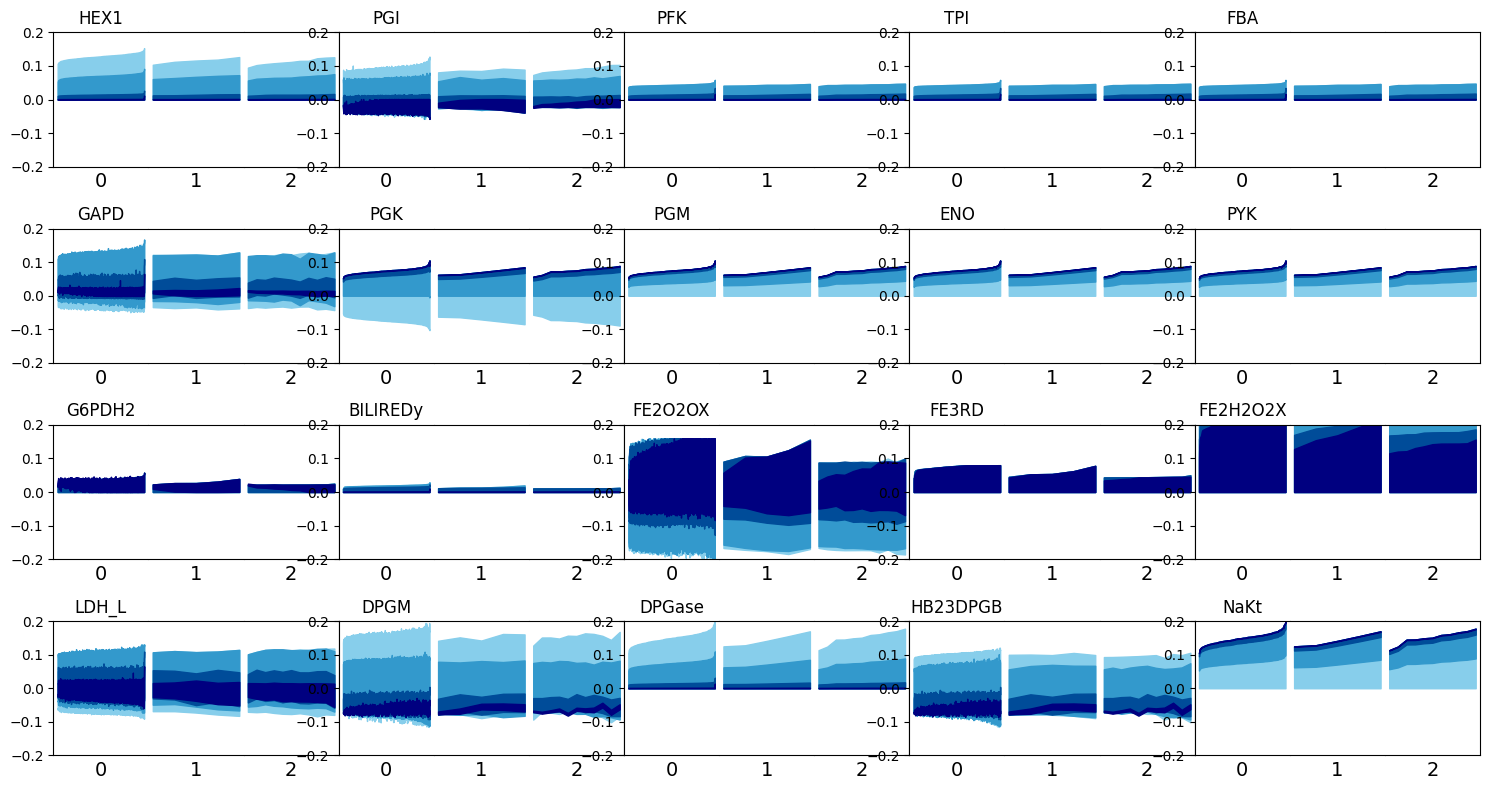

In [68]:
fig = plt.figure(figsize=(15, 8))
zero_one_two_alleles = 3
rows = len(flux_alleles_positions)
cols = len(flux_alleles_positions[0]) * zero_one_two_alleles
optima = [0.0, 0.5, 0.9, 0.99]
optima_colors = ["#87CEEB", "#3399CC", "#004C99", "#000080"]
axes_created = {}
ylim_max = 0.2
ylim_min = -0.2
gs = GridSpec(rows, cols, wspace=0)
for gs_row, day_flux_alleles_positions_row in zip(range(rows), flux_alleles_positions):
    for gs_col_left, alleles_day_flux_group in zip(range(0, cols, zero_one_two_alleles), day_flux_alleles_positions_row):
        for group_idx in range(zero_one_two_alleles):
            alleles, day, flux = alleles_day_flux_group[group_idx]
            if group_idx == 0:
                ax = fig.add_subplot(gs[gs_row, gs_col_left + group_idx])
            else:
                # sharey_axes = axes_created[(gs_row, gs_col_left)]
                # ax = fig.add_subplot(gs[gs_row, gs_col_left + group_idx], sharey=sharey_axes)
                ax = fig.add_subplot(gs[gs_row, gs_col_left + group_idx])
            if group_idx == 0:
                ax.tick_params(right=False)
                ax.spines["right"].set_visible(False)
                ax.set_title(flux)
            elif group_idx == 1:
                ax.tick_params(left=False, right=False)
                ax.spines["left"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.set_yticklabels([])
            else:
                ax.spines["left"].set_visible(False)
                ax.tick_params(left=False)
                ax.set_yticklabels([])
            axes_created[(gs_row, gs_col_left + group_idx)] = ax
            ax.set_ylim(ylim_min, ylim_max)
            for optimum, optimum_color in zip(optima, optima_colors):
                multi_index = (alleles, day, flux, optimum)
                df = df_pcfva_alleles.loc[multi_index].sort_values(by="range")
                y_mins = df["minimum"]
                y_maxs = df["maximum"]
                xs = np.arange(1, len(y_maxs) + 1)
                ax.fill_between(
                    xs,
                    y_mins,
                    y_maxs,
                    color=optimum_color,
                    label=f"{optimum*100:.0f}% Max NaKt",
                )
                ax.set_xlabel(alleles, fontsize=14)
                ax.set_xticks([])
fig.tight_layout()